In [1]:
suppressPackageStartupMessages({
    library(DESeq2)
    library(ggplot2)
    library(rtracklayer)
    library(pheatmap)
    library(RColorBrewer)
    library(ggrepel)
    library(reshape2)
    library(dplyr)
    library(data.table)
    library(tidyr)
    library(ggpubr)
    library(purrr)
    library(patchwork)
    library(pheatmap)
    library(ComplexHeatmap)
    library(org.Mm.eg.db)
    library(edgeR)
    library(org.Mm.eg.db)
})

In [1]:
####################
## Define options ##
####################
LFC_thr = 2
padj_thr = 0.05

# plot options
options(repr.plot.width=15, repr.plot.height=8) 

In [2]:
countData <- as.matrix(read.csv('gene_count_matrix_epiblast.csv', row.names = 'gene_id'))
rownames(countData) = rownames(countData) %>% strsplit('[|]') %>% map(2) # change rownames

colData <- read.csv('phenodata_epi2.csv', row.names = 1)
colData$genotype = gsub("-/-", "null", colData$genotype)
colData$group = paste0(colData$genotype, '_',colData$stage)

ERROR: Error in rownames(countData) %>% strsplit("[|]") %>% map(2): could not find function "%>%"


# Using all samples

In [ ]:
#E5.5, E6.5, E7.5
##Remove ex5.5 results
colE567 <- colData[colData$stage!="ex5.5",]
#colE567 <- colE567[!rownames(colE567) %in% c("E5.5_Stat3null_1", "E6.5_Stat3null_1", "E6.5_Stat3null_2", "E6.5_WT_1", "E6.5_WT_2", "E6.5_WT_3", "E6.5_WT_4", "E7.5_WT_3"), ]
colE567$genotype <- factor(colE567$genotype, levels = c("WT", "Stat3null"))
countDataE567 <- countData[, rownames(colE567)]
rownames(countDataE567) = make.names(rownames(countDataE567), unique=TRUE)
head(countDataE567)

In [ ]:
##Check all sample IDs in colData are also in CountData and match their orders (phenodata.csvとサンプルが噛み合うか確認)
all(rownames(colE567) %in% colnames(countDataE567))
countDataE567 <- countDataE567[, rownames(colE567)]
all(rownames(colE567) == colnames(countDataE567))

In [ ]:
##Create a DESeqDataSet from count matrix and labels (DESeqDataSetを作成）

ddsFullE567 <-DESeqDataSetFromMatrix(countData = countDataE567, colData = colE567, design = ~ stage + genotype + genotype:stage)  # group
ddsFullE567 <- ddsFullE567[rowSums(counts(ddsFullE567)) > 10, ]
ddsFullE567$genotype <- factor(ddsFullE567$genotype, levels = c("WT","Stat3null"))
ddsFullE567$stage <- factor(ddsFullE567$stage, levels = c("E5.5","E6.5", "E7.5")) # does DESeq just not work with 3 values?


# Normalisation
ddsFullE567 <- estimateSizeFactors(ddsFullE567)
normalized_counts <- counts(ddsFullE567, normalized=TRUE)

In [ ]:
#normalization
rld_E567 <- rlog(ddsFullE567, blind = TRUE)
rld_E567$genotype <- factor(rld_E567$genotype, levels = c("WT", "Stat3null"))

In [3]:
counts = assay(rld_E567)

ERROR: Error in assay(rld_E567): could not find function "assay"


In [4]:
head(colData)

ERROR: Error in head(colData): object 'colData' not found


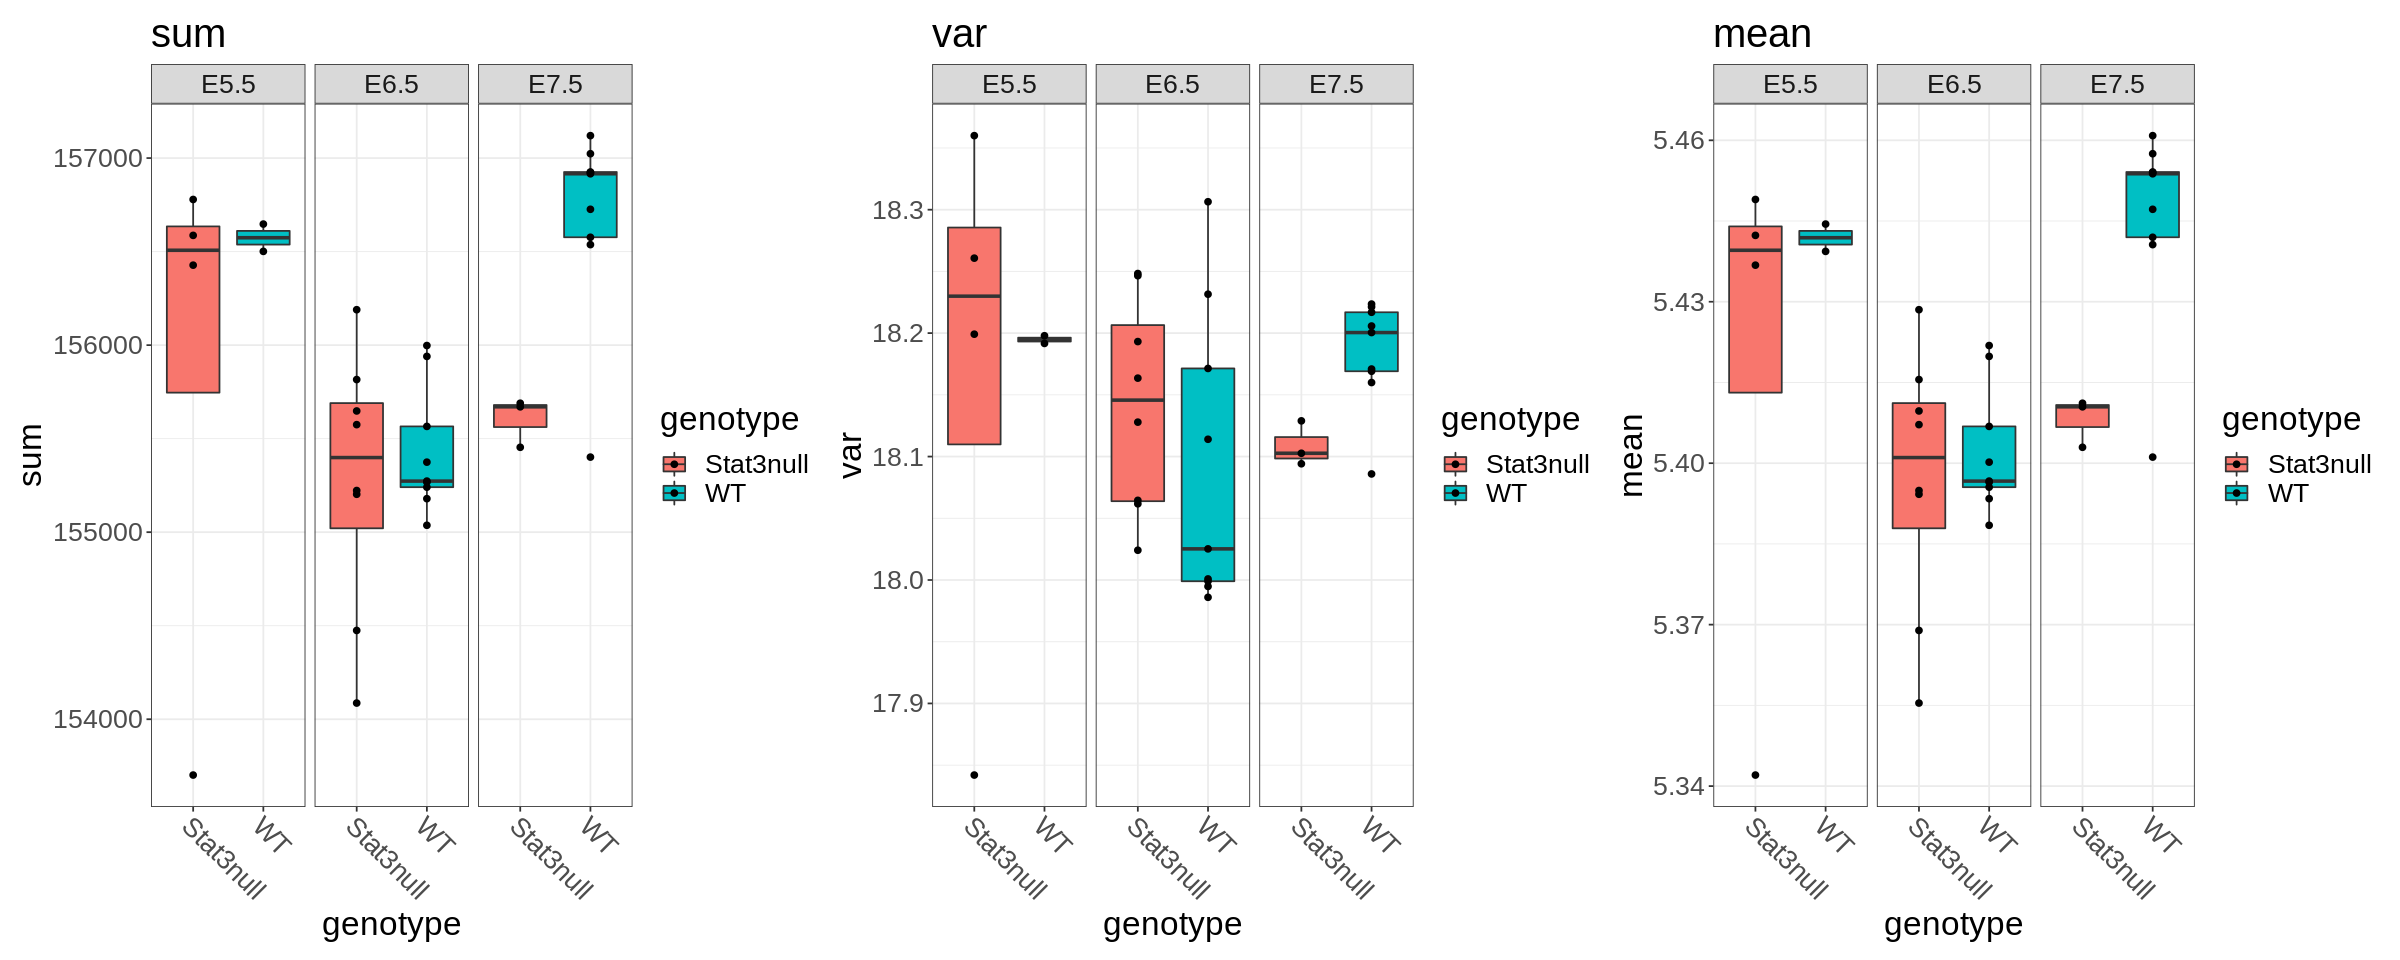

In [10]:
# sample statistics
sample = data.table(sample=colnames(counts), 
                   sum = colSums(counts), 
                   mean = colMeans(counts), 
                   var = colVars(counts))
meta_sample = merge(colData, sample, by.x=0, by.y='sample')

plot_stat = function(x){
    ggplot(meta_sample, aes_string('genotype', x, fill='genotype')) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_point() + 
        viridis::scale_color_viridis() + 
        facet_wrap(~stage) + 
        ggtitle(x) +
        theme_bw() + 
        theme(text=element_text(size=20), 
                   axis.text.x=element_text(angle=-45, hjust=0, vjust=1))
    }
options(repr.plot.width=20, repr.plot.height=8)
plot_stat('sum') + plot_stat('var') + plot_stat('mean')
options(repr.plot.width=10, repr.plot.height=8)

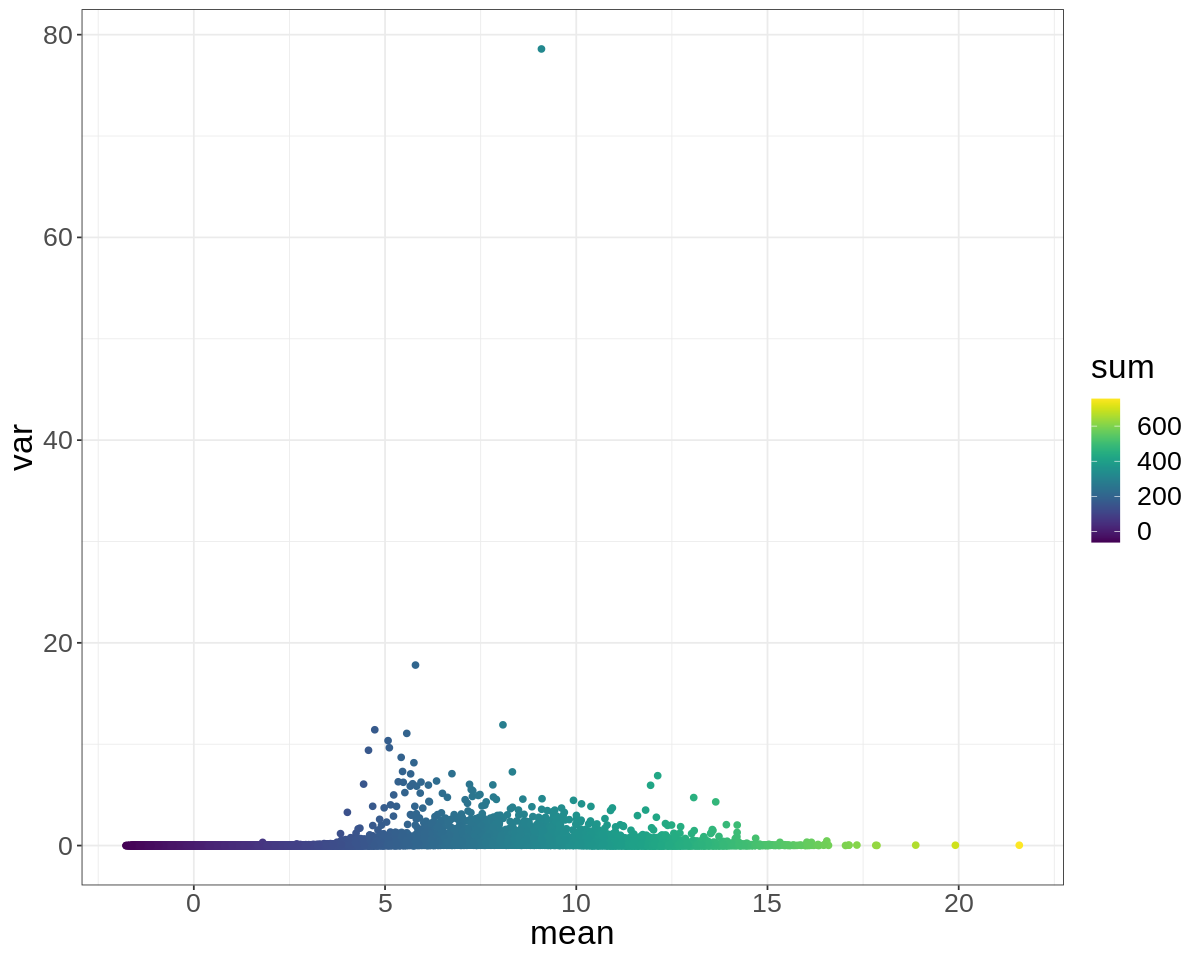

In [11]:
# Gene statistics
genes = data.table(gene=rownames(counts), 
                   sum = rowSums(counts), 
                   mean = rowMeans(counts), 
                   var = rowVars(counts))

ggplot(genes, aes(mean, var, col=sum)) + 
    geom_point() + 
    viridis::scale_color_viridis() + 
    theme_bw() + theme(text=element_text(size=20))

In [12]:
head(genes)

gene,sum,mean,var
<chr>,<dbl>,<dbl>,<dbl>
Xkr4,231.135796,6.6038799,0.269979119
Gm18956,-6.112773,-0.1746507,0.000413513
Gm37686,80.443991,2.2983997,0.004461984
Gm37329,118.599845,3.3885670,0.013179706
Gm38148,185.521000,5.3006000,0.110174603
Gm37180,163.737880,4.6782251,0.049120421


In [13]:
genes.long = genes %>% melt(id.vars = 'gene', variable.name = "stat", value.name = 'value')

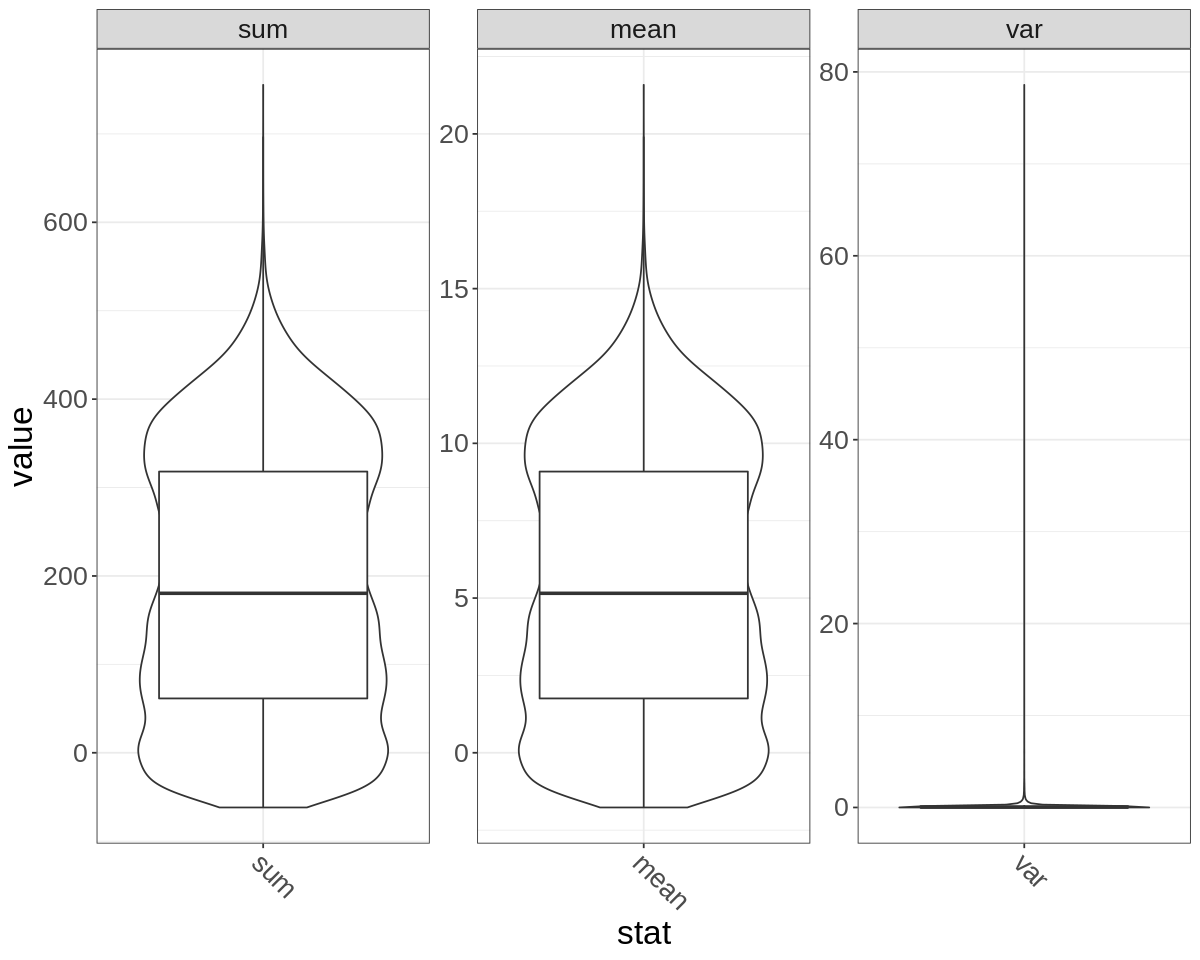

In [14]:
   ggplot(genes.long, aes(stat,value)) + 
geom_violin() +         
geom_boxplot(outlier.shape = NA) + 
  #      geom_point() + 
        facet_wrap(~stat, scales='free') +
        theme_bw() + 
        theme(text=element_text(size=20), 
                   axis.text.x=element_text(angle=-45, hjust=0, vjust=1))

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

Warning message:
“Removed 1346 rows containing non-finite values (stat_bin).”
Warning message:
“Removed 2 rows containing missing values (geom_bar).”


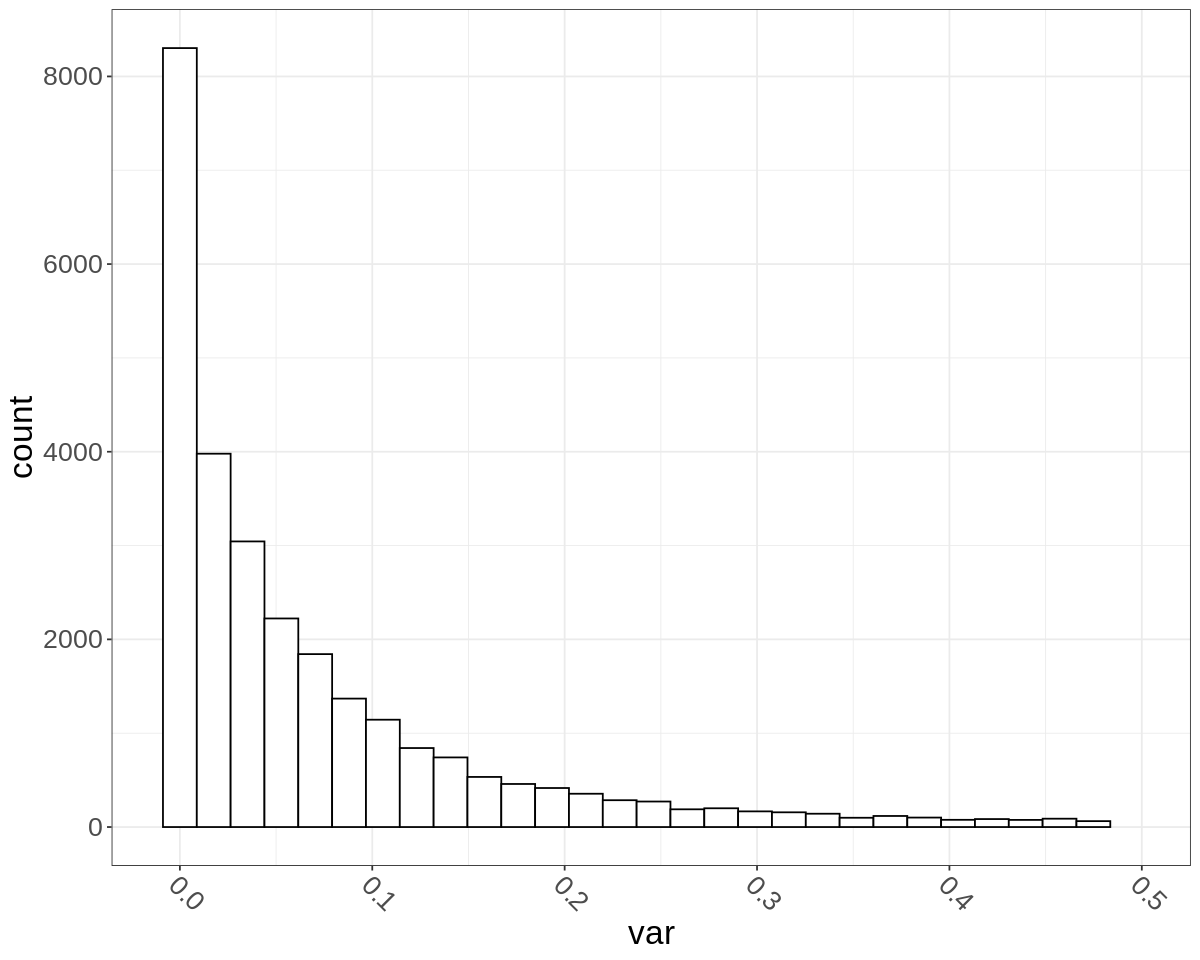

In [15]:
ggplot(genes, aes(var)) + 
    geom_histogram(col='black', fill='white') + 
    xlim(-0.01,0.5) + 
    theme_bw() + 
    theme(text=element_text(size=20), 
        axis.text.x=element_text(angle=-45, hjust=0, vjust=1))

In [16]:
#Heatmap of the sample-to-sample distances
#removing genes that are not variable across any of the samples
var_genes = genes[var>0.02, gene]

counts_cor <- cor(counts[var_genes,])
colors <- colorRampPalette(c("blue","white","red"))(99)
annocolors <- list(
  genotype = c("WT"="#00afbb", "Stat3null"="#fc4e07"),
  stage = c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")
)
colData$genotype <- factor(colData$genotype, levels = c("WT", "Stat3null"))

options(repr.plot.width=15, repr.plot.height=8) 
pheatmap(counts_cor,
         annotation_col = colData[,c('genotype', 'stage')],
         annotation_colors = annocolors,
         col=colors)

ERROR: Error: number of observations in top annotation should be as same as ncol of
the matrix.


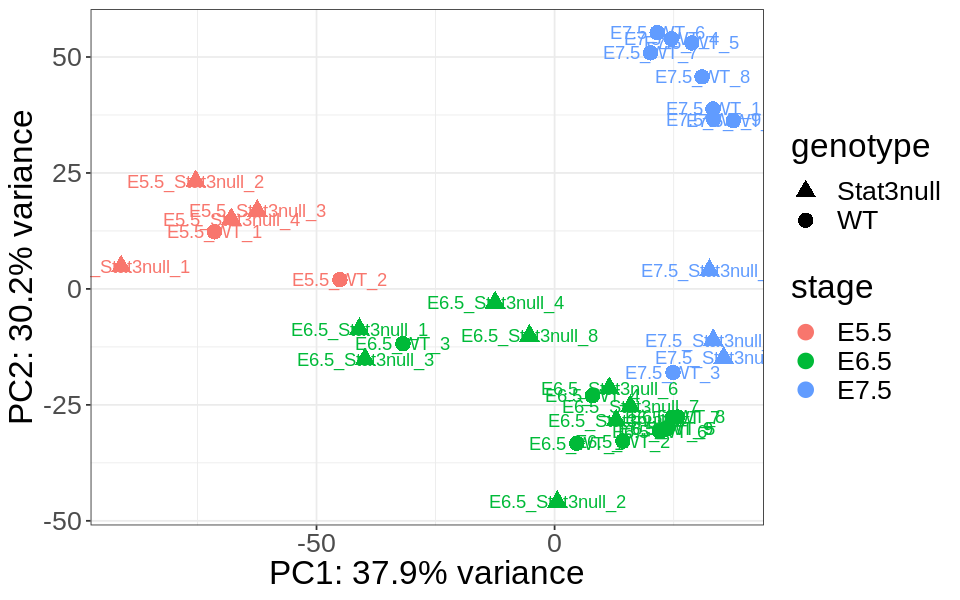

In [22]:
# Select variable genes
var_genes = genes[order(-var), gene] %>% head(5000)

# PCA 
pca = prcomp(t(as.matrix(counts[var_genes,])), scale=TRUE) # Does scale need to be TRUE?
meta_pca = cbind(meta_sample, pca$x)


options(repr.plot.width=8, repr.plot.height=5) 

# Plot
ggplot(meta_pca, aes(PC1, PC2, col=stage, shape=genotype)) + 
    scale_shape_manual(values=c('Stat3null'=17, 'WT'=16))+
    geom_point(size=4) +
    geom_text(label=rownames(meta_pca)) +
    theme_bw() + 
    labs(x = paste0('PC1: ', round(pca$sdev[1],1), '% variance'),
         y =  paste0('PC2: ', round(pca$sdev[2],1), '% variance')) + 
    theme(text=element_text(size=20, color='black'))

In [ ]:
# DEseq per stage
DEgenes = lapply(unique(colE567$stage), function(x){ # only on first one as test
  meta = colE567[colE567$stage == x,]
  counts.mtx = countDataE567[, rownames(meta)]
# remove non-expressed genes to get higher p values
  counts.mtx = counts.mtx[rowSums(counts.mtx) > 10, ]
  dds = DESeqDataSetFromMatrix(countData = counts.mtx, colData = meta, design = ~ genotype)  # group
  dds$genotype <- factor(dds$genotype, levels = c("WT","Stat3null"))

  deseq = DESeq(dds)
  res = results(deseq, contrast = c('genotype', "Stat3null", "WT")) %>% 
                as.data.table(., keep.rownames=T) %>% 
                setnames('rn', 'gene') %>%
                .[, sig:=padj <= padj_thr & abs(log2FoldChange) >= LFC_thr & !is.na(padj)] %>%
                .[, stage:=x]
  return(res)
}) 

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [22]:
marker_type = data.table('naive' = c('Pou5f1',
'Sox2',
'Nanog',
'Zfp42',
'Dppa3',
'Esrrb',
'Tfcp2l1',
'Klf2',
'Klf4',
'Klf5',
'Fgf4'),
                         'primed' = c('Pou3f1',
'Otx2',
'Fgf5',
'Nodal',
'L1td1',
'Etv5',
'Utf1'),
                         'neuroectoderm' = c('Sox1',
'Pax6',
'Hoxb2',
'Hoxa1',
'Igf2',
'Sox21',
'Ncam1'),
                         'Primitive streak' = c('T',
'Mixl1',
'Wnt3',
'Wnt3a',
'Wnt5a',
'Wnt8a',
'Fzd10',
'Tagf1',
'Hoxb1',
'Lefty2',
'Tbx6',
'Foxh1',
'Egf8',
'Zic2')) %>% 
        melt(variable.name = "celltype", value.name = "gene", measure.vars=colnames(.)) %>% unique(by=c('celltype', 'gene'))

Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 1 has 11 rows but longest item has 14; recycled with remainder.”


Warning message:
“Removed 16080 rows containing missing values (geom_point).”


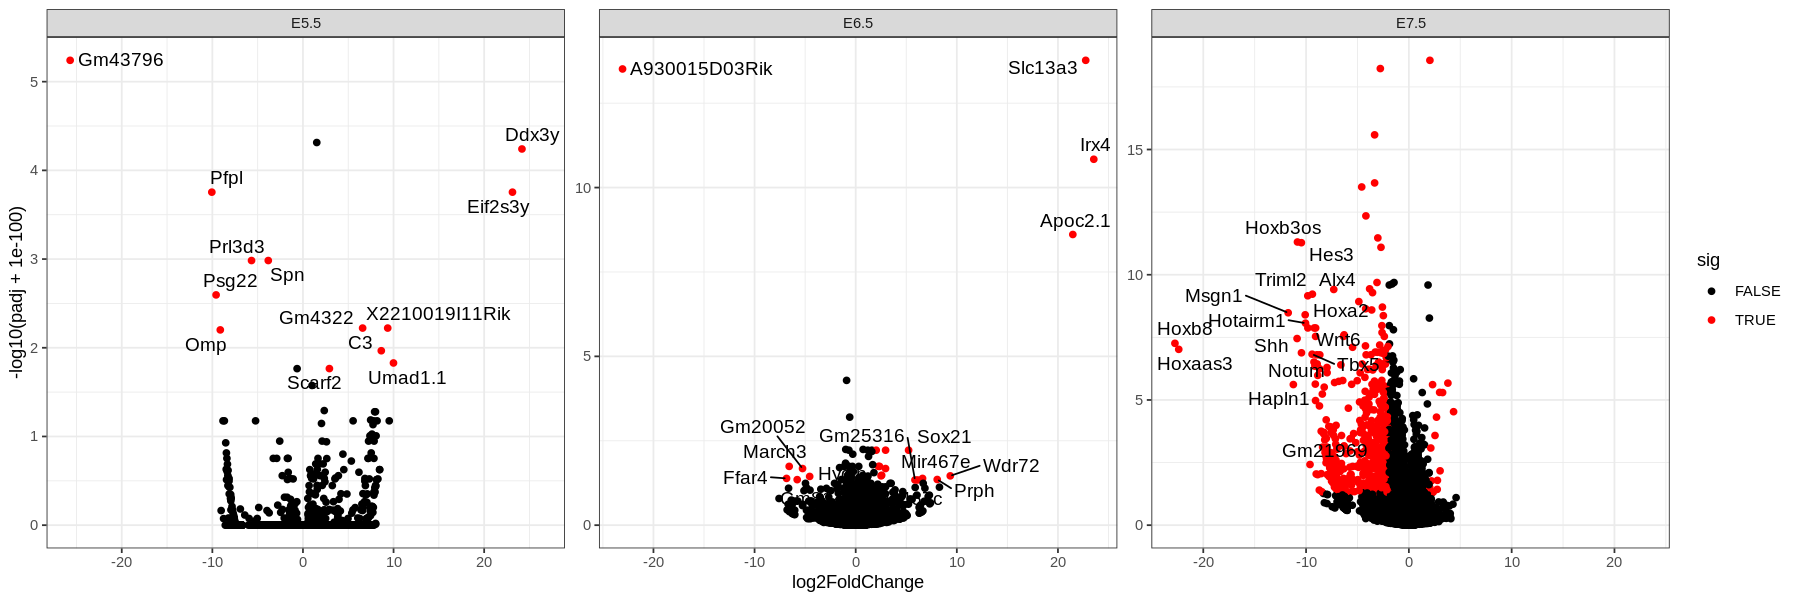

In [23]:
to.plot = rbindlist(DEgenes)
labels = to.plot[sig==TRUE,] %>% .[order(-abs(log2FoldChange)),] %>% .[,head(.SD, 15), by=stage]

options(repr.plot.width=15, repr.plot.height=5) 

ggplot(to.plot, aes(log2FoldChange, -log10(padj+1e-100), col=sig)) + 
    geom_point() + 
    scale_color_manual(values=c('black', 'red')) +
    ggrepel::geom_text_repel(data=labels, aes(x=log2FoldChange, y=-log10(padj+1e-100), label=gene), 
                             max.overlaps=Inf, size=4, col='black') +
    facet_wrap(~stage, scales='free') + 
    theme_bw()

In [24]:
normalized_counts = assay(rlog(ddsFullE567, blind = TRUE))

rlog() may take a few minutes with 30 or more samples,
vst() is a much faster transformation



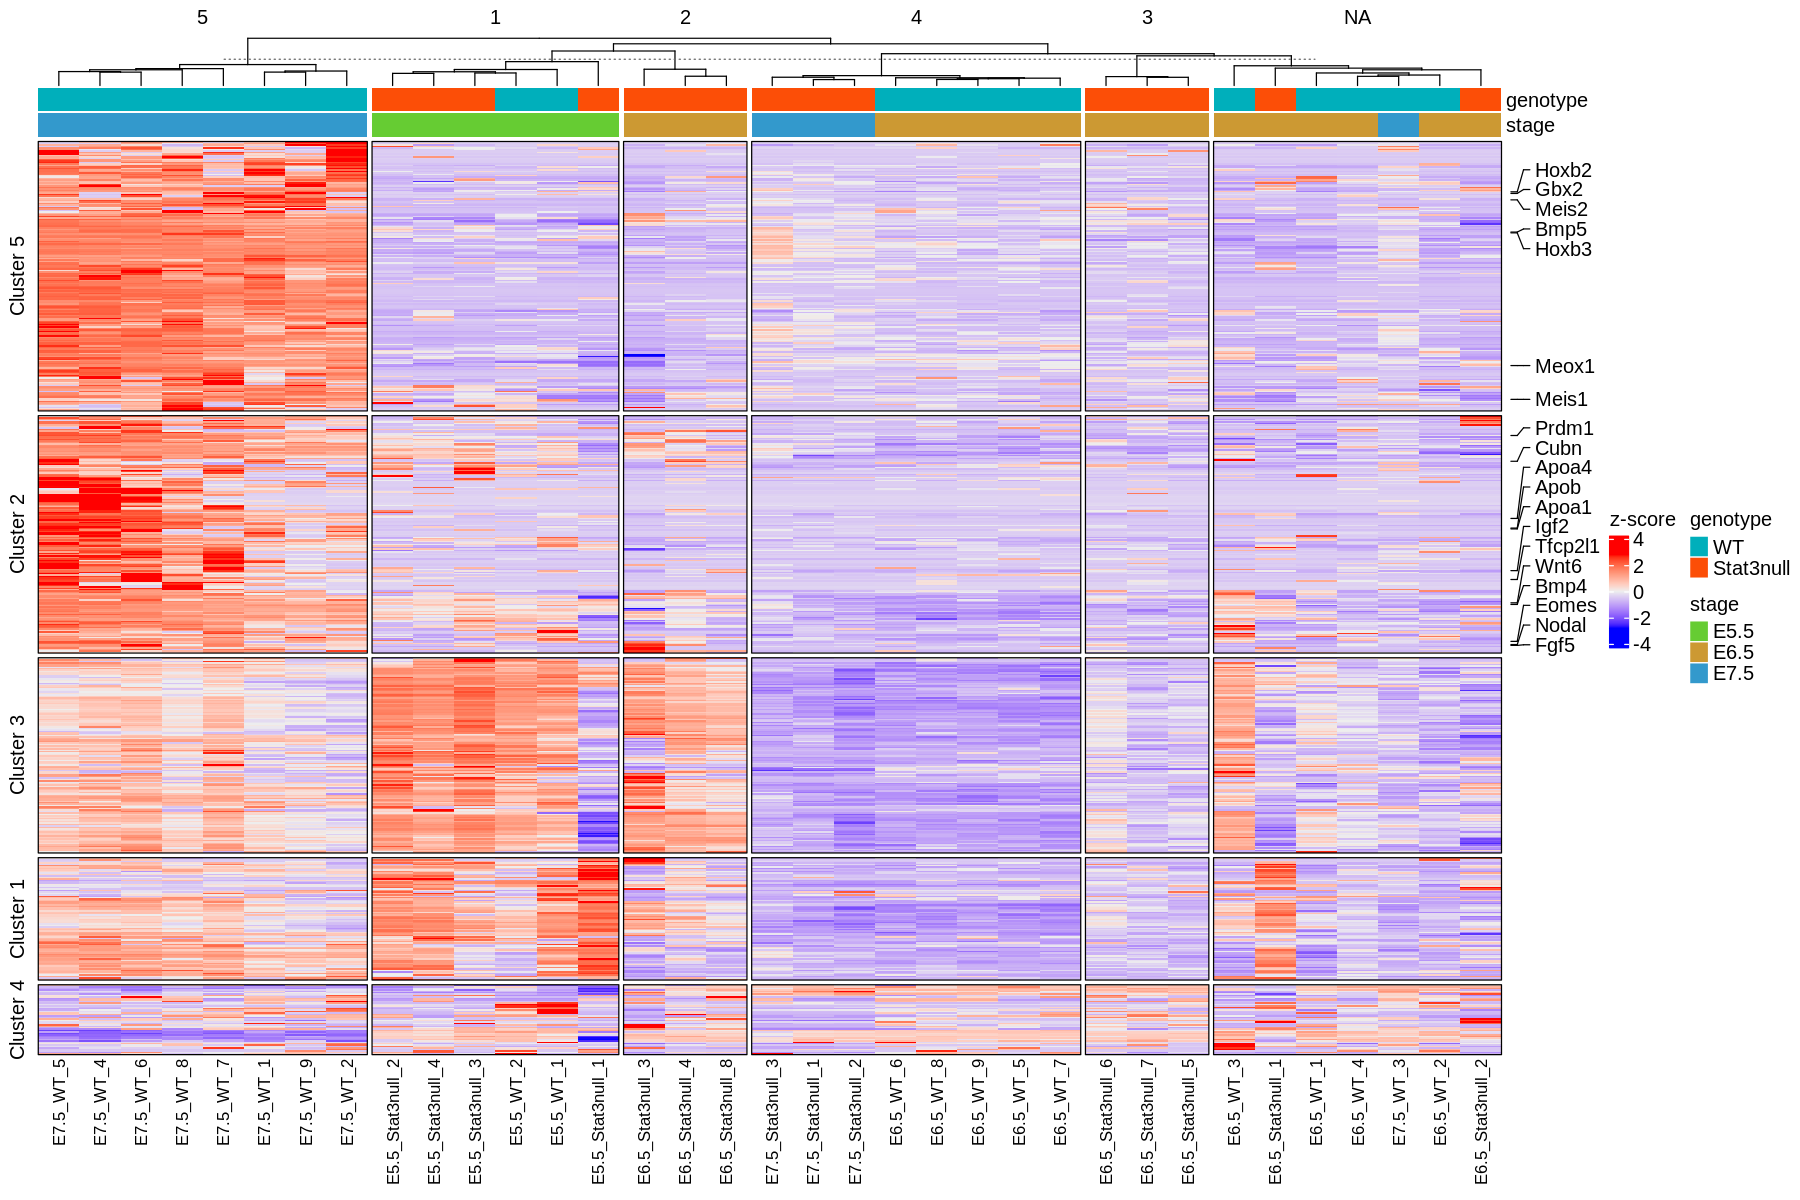

In [27]:
opts = list()
for(i in 5){ # after looking at clustering 1 to 10 gene clusters, 4 looks best
opts$nclust = i

# get normalized counts of genes that are significant in any of the timepoints
heatmap.mtx = normalized_counts[unique(to.plot[sig==TRUE, gene]), ]

heatmap_scaled.mtx <- t(scale(t(heatmap.mtx)))

#perform k-means with 4 centers and take a look at the gene-to-cluster assignment.
set.seed(1234)
kclus <- kmeans(heatmap_scaled.mtx, opts$nclust)

#use the split parameter of Heatmap() in order to split the heatmap based on the k-means result:
split <- paste0("Cluster ", kclus$cluster)
# fix order of the clusters to have 1 to 4, top to bottom
split <- factor(split, levels = paste0('Cluster ', 1:opts$nclust))


list = c("T", "Axin2", "Cer1", "Dkk1","Wnt3a", "Tbx3","Wnt6", "Wnt8a","Wnt5a", "Igf2", "Bmp2","Bmp4", "Bmp5", "Fgf5", "Fgf3","Fgf8", "Cer1", "Prdm1", "Nkx1-2", "Cubn", "Apoe1", "Spry4", "Tead1","Apob", "Id1","Apoa1", "Apoa4" , "Sox7", "Eomes", "Hoxb2", "Hoxb3","Gbx2", "Nodal", "Notch1", "Nanog", "Esrrb", "Tfcp2l1", "Meox1", "Meox2", "Meis1", "Meis2")
genelabs <- rowAnnotation(Genes = anno_mark(at=which(rownames(heatmap_scaled.mtx) %in% list), labels = rownames(heatmap_scaled.mtx)[which(rownames(heatmap_scaled.mtx) %in% list)]))


#top annotation
anno <- HeatmapAnnotation(df=colData(ddsFullE567)[, c("genotype", "stage")], 
                          col = list(genotype=c("WT"="#00afbb", "Stat3null"="#fc4e07"), 
                                     stage=c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")),
                          annotation_legend_param = list(title_gp = gpar(fontsize = 12),
                                                         labels_gp = gpar(fontsize = 12)))


hm <- Heatmap(heatmap_scaled.mtx, 
              split = split, 
              name = "z-score", 
              top_annotation = anno,
            #  cluster_row_slices = FALSE, 
              cluster_rows = TRUE,
              column_split = ddsFullE567$cluster, 
              cluster_columns = TRUE,
              show_row_dend = FALSE, 
              row_gap = unit(1, "mm"), 
              column_gap = unit(1, "mm"), 
              border = TRUE, 
              row_title_gp = gpar(fontsize = 12),
              row_names_gp = gpar(fontsize = 10), 
              column_title_gp = gpar(fontsize = 12), 
              column_names_gp = gpar(fontsize = 10),
              heatmap_legend_param = list(title_gp=gpar(fontsize = 12),
                                          labels_gp=gpar(fontsize = 12)
                                          )
              )
pdf("Heatmap100522_c5.pdf", width = 7.5, height = 10)
draw(hm + genelabs)
dev.off()
    
options(repr.plot.width=15, repr.plot.height=10) 
draw(hm + genelabs)
}

In [28]:
# Turn matrix in to long format 
mtx_long = as.data.table(heatmap.mtx, keep.rownames=T) %>% 
    setnames('rn', 'gene') %>% 
    melt(id.vars = "gene",
         variable.name = "sample", value.name = "expr") %>%
    merge(as.data.table(colData, keep.rownames=T), by.x='sample', by.y='rn') %>%
    .[,mean_expr := mean(expr), by=c('group', 'gene')] %>% unique(by=c('group', 'gene')) %>%
    .[,cluster:=NULL] %>%
    merge(as.data.table(kclus$cluster,keep.rownames=T), by.x='gene', by.y='V1') %>% 
    setnames('V2', 'cluster') %>%
    .[,zscore:=scale(mean_expr), by='gene']

In [38]:
DEGenes = data.table(gene = rownames(heatmap_scaled.mtx), cluster = split)
entrez = mapIds(org.Mm.eg.db, DEGenes$gene, 'ENTREZID', 'SYMBOL')
DEGenes$entrez = entrez

'select()' returned 1:1 mapping between keys and columns



In [45]:
GO_terms = lapply(unique(DEGenes$cluster), function(x){
    go <- goana(DEGenes[cluster==x, entrez], species="Mm")
    GO = as.data.table(go, keep.rownames=T)[order(P.DE),] %>% .[Ont=='BP'] %>% head(10) %>%
        .[,Term:=factor(Term, levels=Term)] %>%
        .[,cluster:=x]
    
    return(GO)
    })

In [46]:
unique(mtx_long$cluster)

[1] 2 3 4 5 1

In [41]:
library(org.Mm.eg.db)

In [47]:
plot_expr = function(cl = 1){
    ggplot(mtx_long[cluster==cl], aes(stage, zscore, col=genotype, group=interaction(genotype, gene))) + 
        geom_line(data=mtx_long[genotype=='WT' & cluster==cl], size=0.1, col="#e6f6f7") + # 
        geom_line(data=mtx_long[genotype=='Stat3null' & cluster==cl], size=0.1, col="#fcdccf") + # 
        ggtitle(paste0('cluster ', cl)) + 
        stat_summary(aes(group=interaction(cluster, genotype)), fun='mean', geom="line",size=2) +
        scale_color_manual(values = c(WT="#00afbb", Stat3null="#fc4e07")) +
        scale_x_discrete(expand = c(0.05, 0)) + 
        theme_bw() + 
        theme(legend.position='left', 
              text=element_text(color='black', size=15),
              axis.title.x=element_blank()) # 
}

GO_terms.plot = GO_terms %>% rbindlist()

plot_go = function(cl = 1){
    ggplot(GO_terms.plot[cluster==paste0('Cluster ',cl)][order(-P.DE),][,Term:=factor(Term, levels=Term)], aes(Term, -log10(P.DE))) +
    geom_bar(stat='identity', col='black', fill=scales::hue_pal()(5)[cl]) + 
    coord_flip() + 
    ggtitle('') +
    theme_bw() + 
    theme(text=element_text(size=15),
         legend.position='none',
         axis.title.y=element_blank(),
         axis.text.y=element_text(color='black'),
         axis.title.x=element_blank())
}

In [48]:
devtools::install_github("thomasp85/patchwork")

pillar      (1.8.0 -> 1.8.1) [CRAN]
viridisLite (0.4.0 -> 0.4.1) [CRAN]
scales      (1.2.0 -> 1.2.1) [CRAN]


Installing 3 packages: pillar, viridisLite, scales

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



✔  checking for file ‘/tmp/RtmpuWKE3V/remotes323680692cc/thomasp85-patchwork-c14c960/DESCRIPTION’ (478ms)
─  preparing ‘patchwork’:
✔  checking DESCRIPTION meta-information
─  checking for LF line-endings in source and make files and shell scripts
─  checking for empty or unneeded directories
─  building ‘patchwork_1.1.2.9000.tar.gz’
   


In [49]:
library(patchwork)
options(repr.plot.width=15, repr.plot.height=4) 

plots = list()
for(i in 1:opts$nclust){
    p1 = plot_expr(i)
    plots[[i]] = p1
}

goplots = list()
for(i in 1:opts$nclust){
    p2 = plot_go(i)
    goplots[[i]] = p2
}

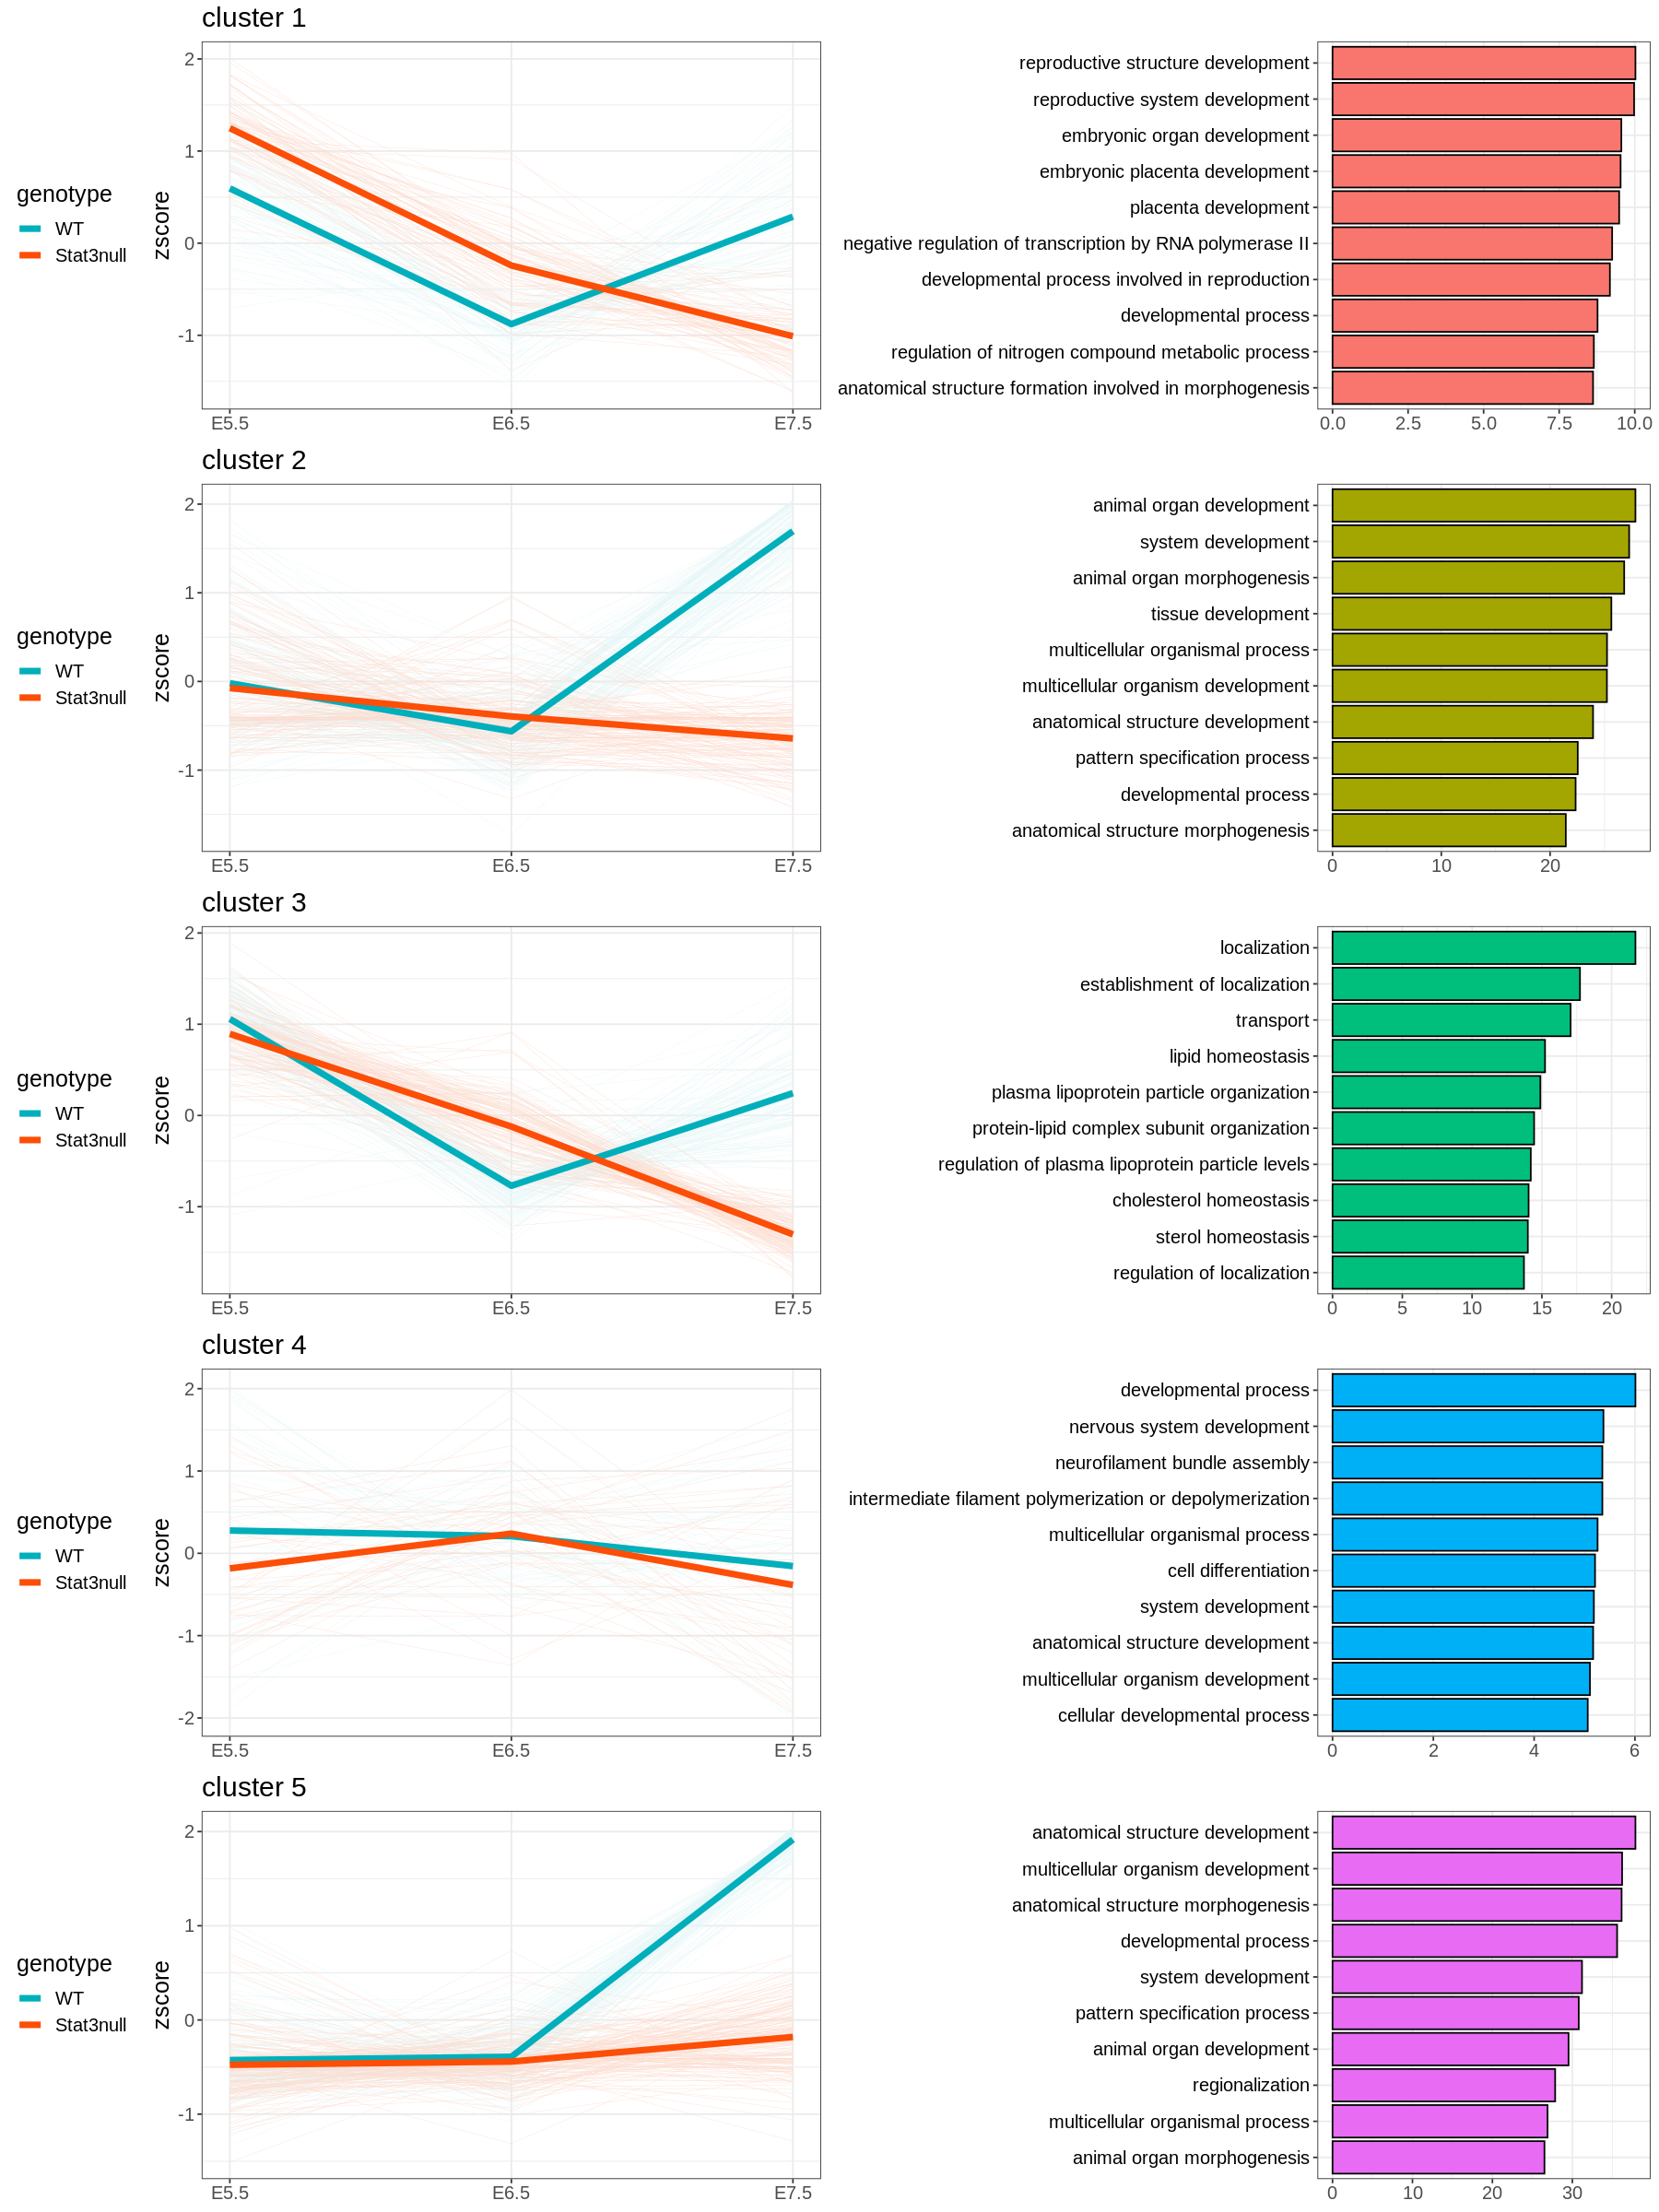

In [50]:
p_expr = ggarrange(plotlist = plots, ncol=1, align ='v')
p_go = ggarrange(plotlist = goplots, ncol=1, align ='v')
options(repr.plot.width=15, repr.plot.height=20) 

ggarrange(p_expr,p_go)

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



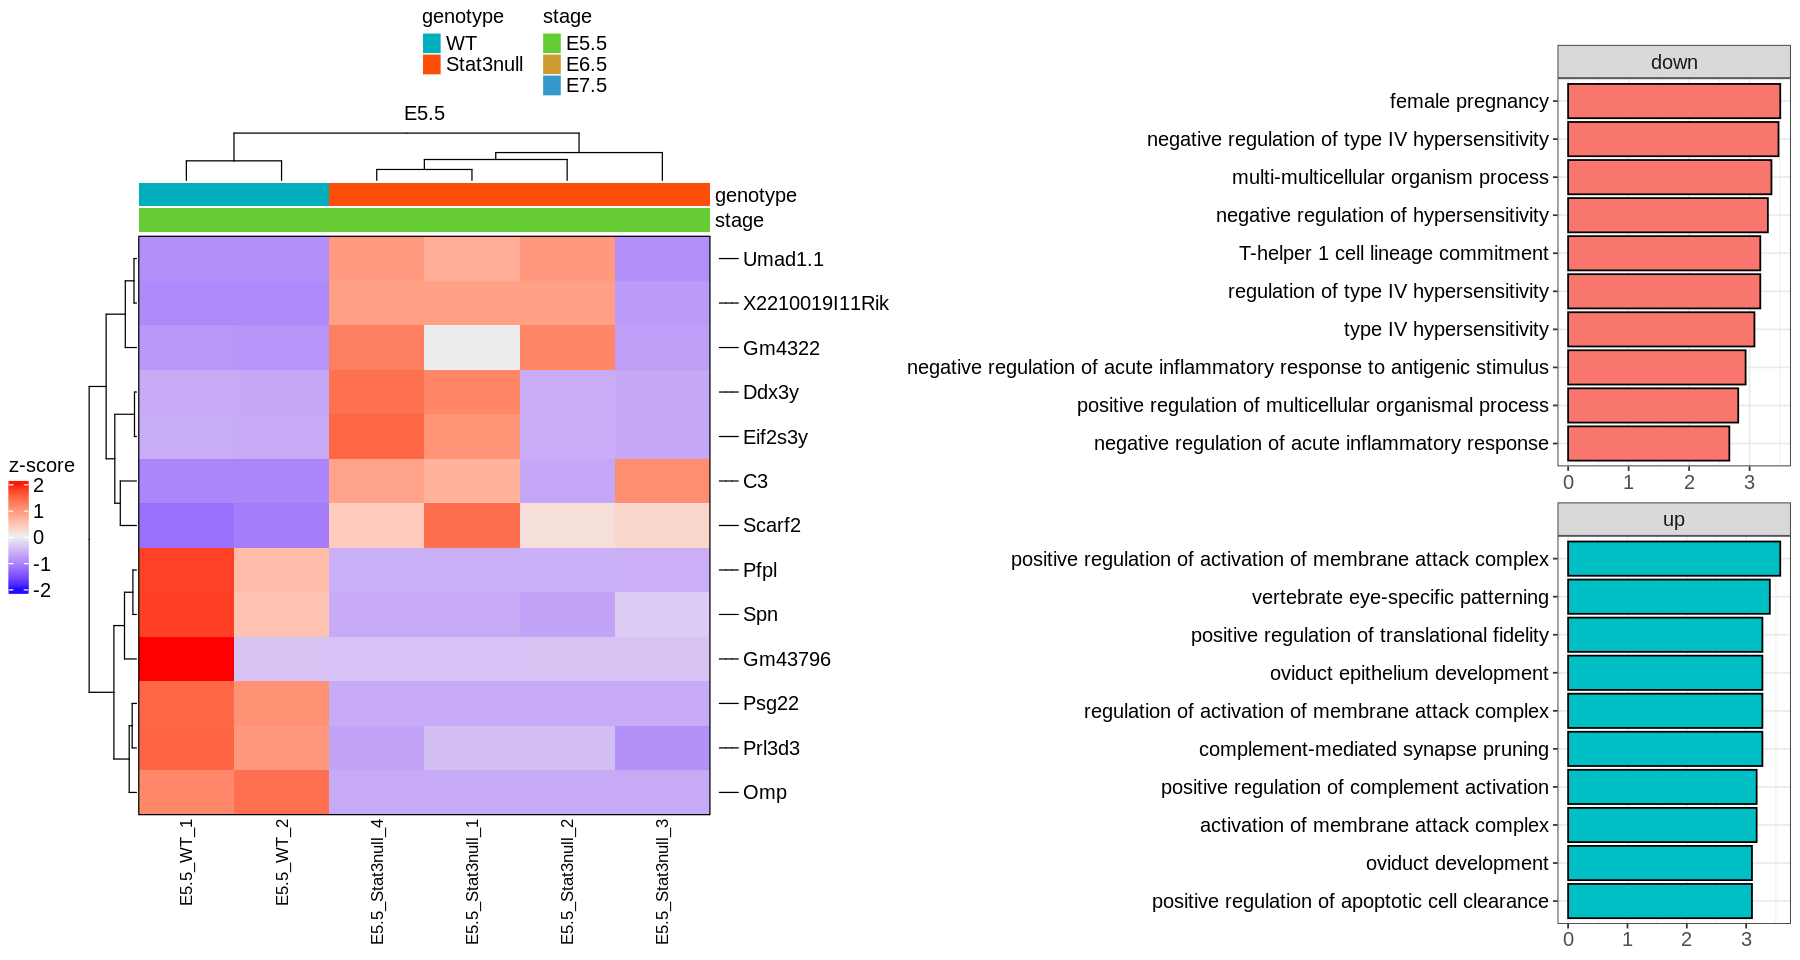

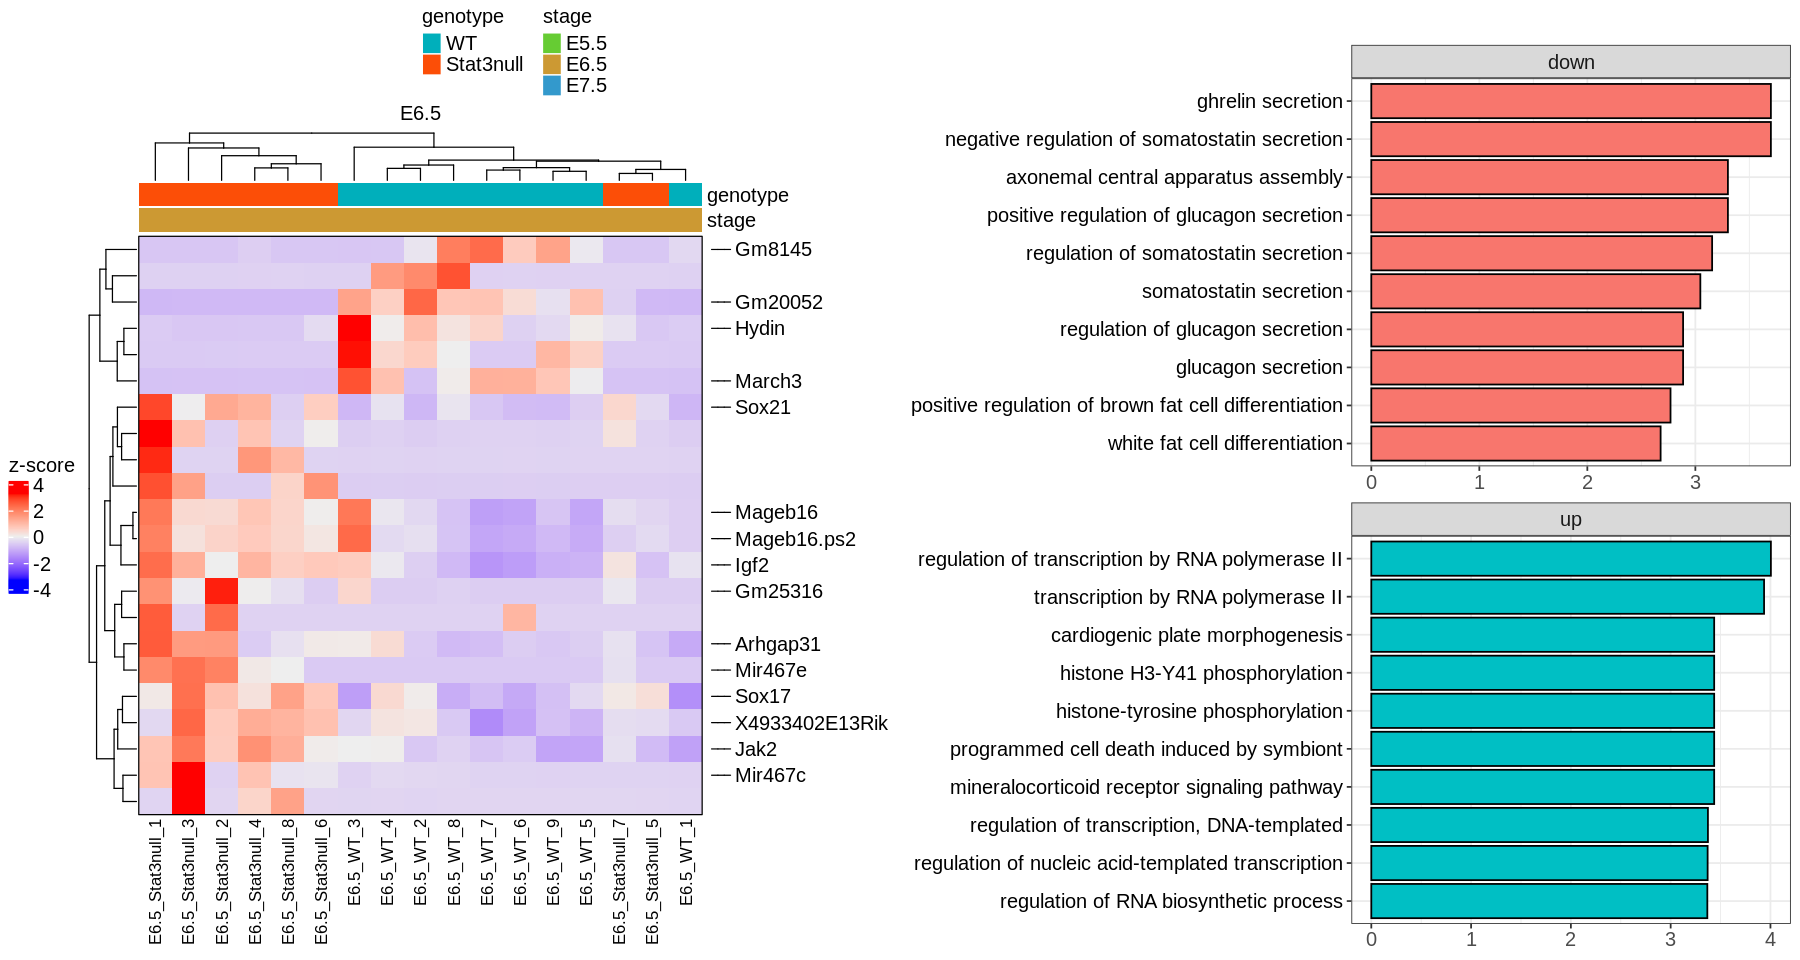

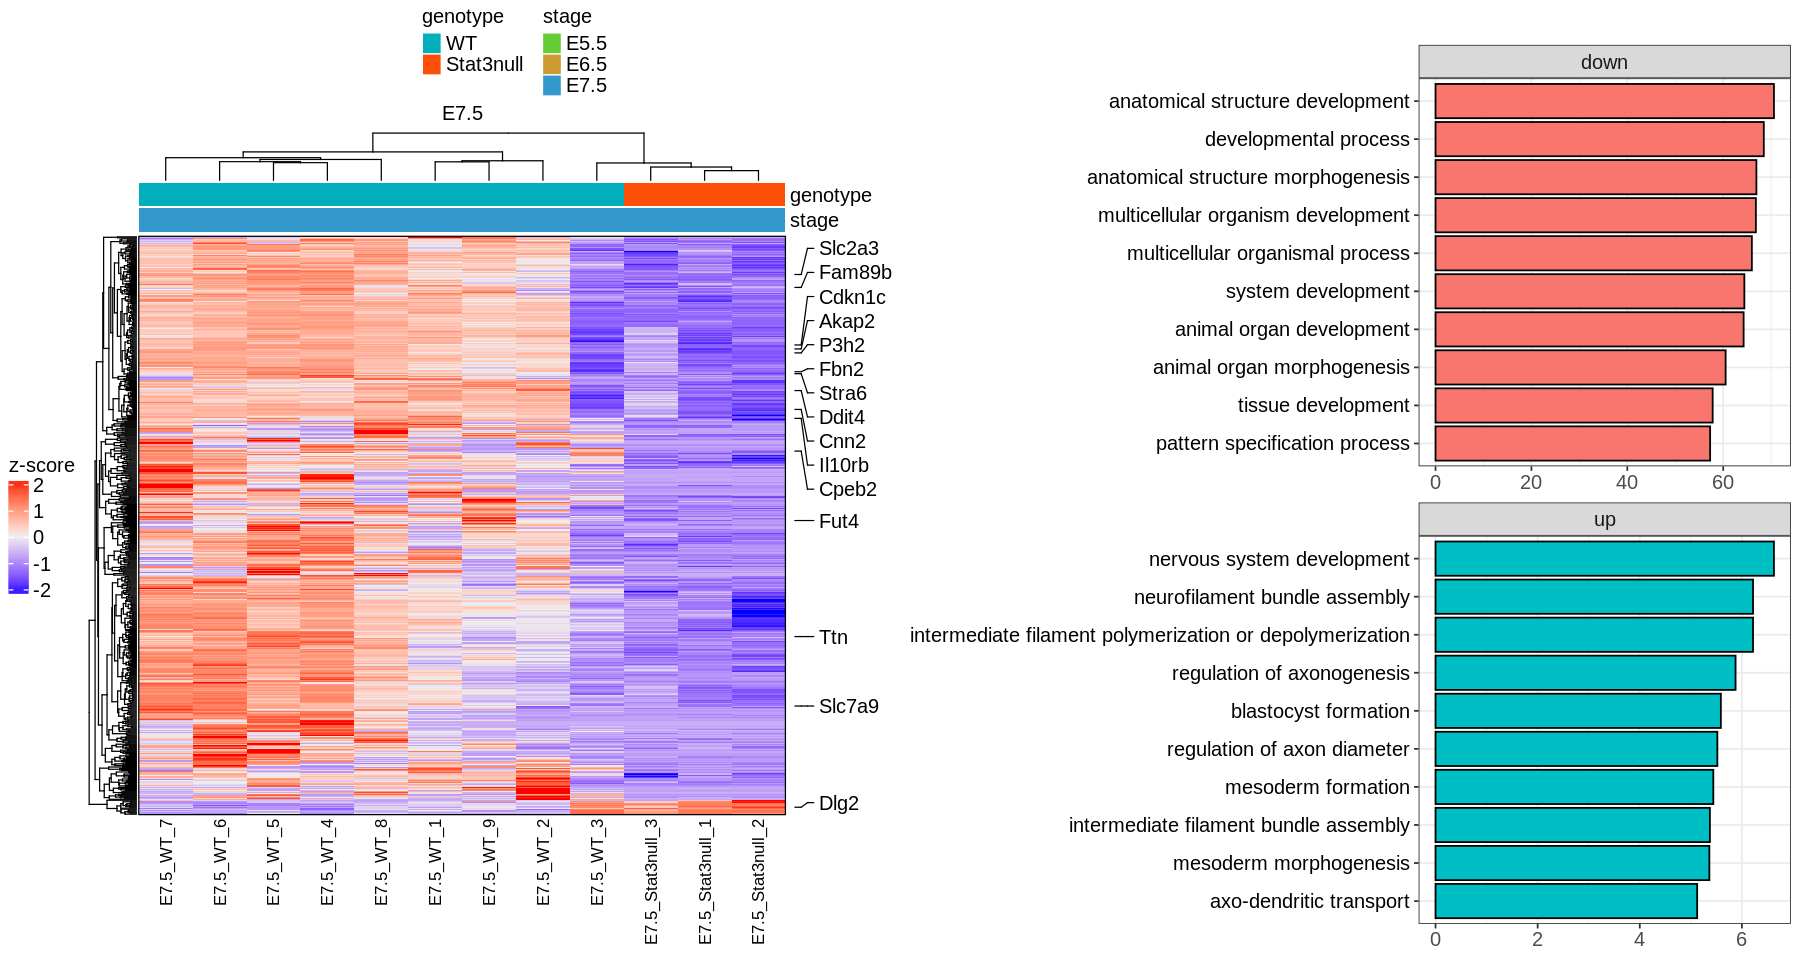

In [51]:
# Per timepoint
for(i in unique(to.plot$stage)){
tp = i
to.plot_tmp = to.plot[stage==tp & sig == TRUE]

# heatmap
heatmap.mtx = normalized_counts[unique(to.plot_tmp[sig==TRUE, gene]), grep(tp, colnames(normalized_counts))]

heatmap_scaled.mtx <- t(scale(t(heatmap.mtx)))

genes = to.plot_tmp[order(abs(log2FoldChange)),]$gene %>% head(15)
genelabs <- rowAnnotation(Genes = anno_mark(at=which(rownames(heatmap_scaled.mtx) %in% genes), labels = rownames(heatmap_scaled.mtx)[which(rownames(heatmap_scaled.mtx) %in% genes)]))

#top annotation
anno <- HeatmapAnnotation(df=colData(ddsFullE567)[colData(ddsFullE567)$stage==tp, c("genotype", "stage")], 
                          col = list(genotype=c("WT"="#00afbb", "Stat3null"="#fc4e07"), 
                                     stage=c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")),
                          annotation_legend_param = list(title_gp = gpar(fontsize = 12),
                                                         labels_gp = gpar(fontsize = 12)))

hm = Heatmap(heatmap_scaled.mtx,
        column_title = i,
        name = "z-score", 
        top_annotation=anno,
        row_gap = unit(1, "mm"), 
        column_gap = unit(1, "mm"), 
        border = TRUE, 
        row_title_gp = gpar(fontsize = 12),
        row_names_gp = gpar(fontsize = 10), 
        column_title_gp = gpar(fontsize = 12), 
        column_names_gp = gpar(fontsize = 10),
        heatmap_legend_param = list(title_gp=gpar(fontsize = 12),
        labels_gp=gpar(fontsize = 12)
))

# GO
up = to.plot_tmp[log2FoldChange>0, gene]
entrez = mapIds(org.Mm.eg.db, up, 'ENTREZID', 'SYMBOL')
up_entrez = entrez
up_GO = as.data.table(goana(up_entrez, species="Mm"), 
                      keep.rownames=T)[order(P.DE),] %>% .[Ont=='BP'] %>% head(10) %>%
    .[,Term:=factor(Term, levels=Term)] %>%
    .[,direction:='up']

down = to.plot_tmp[log2FoldChange<0, gene]
entrez = mapIds(org.Mm.eg.db, down, 'ENTREZID', 'SYMBOL')
down_entrez = entrez
down_GO = as.data.table(goana(down_entrez, species="Mm"), 
                      keep.rownames=T)[order(P.DE),] %>% .[Ont=='BP'] %>% head(10) %>%
    .[,Term:=factor(Term, levels=Term)] %>% 
    .[,direction:='down']

GO_terms.plot = rbind(up_GO, down_GO)

GO_plot = ggplot(GO_terms.plot[order(-P.DE),][,Term:=factor(Term, levels=Term)], aes(Term, -log10(P.DE), fill=direction)) +
    geom_bar(stat='identity', col='black') + 
    coord_flip() + 
    ggtitle('') +
    theme_bw() + 
    facet_wrap(~direction, scales='free', ncol=1) + 
    theme(text=element_text(size=15),
         legend.position='none',
         axis.title.y=element_blank(),
         axis.text.y=element_text(color='black'),
         axis.title.x=element_blank())

options(repr.plot.width=15, repr.plot.height=8) 
print(ggarrange(grid.grabExpr(draw(hm + genelabs, 
                             annotation_legend_side = "top", 
                             heatmap_legend_side = "left")), 
          GO_plot))
}